In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

X_train = np.load(
    "X_train_20step.npy",
    mmap_mode="r"
)

y_train = np.load(
    "y_train_20step.npy",
    mmap_mode="r"
)

X_test = np.load(
    "X_test_20step.npy",
    mmap_mode="r"
)

y_test = np.load(
    "y_test_20step.npy",
    mmap_mode="r"
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Device: cpu
X_train: (44325, 20, 105)
y_train: (44325,)
X_test : (10075, 20, 105)
y_test : (10075,)


In [3]:
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size=105,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        last_output = output[:, -1, :]

        prediction = self.regressor(last_output)

        return prediction.squeeze(1)


model = LSTMRegressor(
    input_size=105,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
)

model.load_state_dict(
    torch.load(
        "best_lstm_rul.pt",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best LSTM model loaded.")

Best LSTM model loaded.


In [4]:
y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train))

print("Training RUL mean:", y_mean)
print("Training RUL std :", y_std)

Training RUL mean: 88.34149169921875
Training RUL std : 70.04686737060547


In [5]:
class RULSequenceDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        X_item = torch.tensor(
            self.X[idx],
            dtype=torch.float32
        )

        y_item = torch.tensor(
            self.y[idx],
            dtype=torch.float32
        )

        return X_item, y_item


test_dataset = RULSequenceDataset(
    X_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)


predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        pred_scaled = model(X_batch)

        pred = (
            pred_scaled.cpu().numpy()
            * y_std
            + y_mean
        )

        predictions.extend(pred)
        actuals.extend(y_batch.numpy())


y_test_actual = np.array(actuals)
y_test_pred = np.array(predictions)

print("Actual shape     :", y_test_actual.shape)
print("Prediction shape :", y_test_pred.shape)

Actual shape     : (10075,)
Prediction shape : (10075,)


In [6]:
lstm_mae = mean_absolute_error(
    y_test_actual,
    y_test_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_test_pred
    )
)

lstm_r2 = r2_score(
    y_test_actual,
    y_test_pred
)

print("===== FINAL LSTM TEST RESULTS =====")
print(f"MAE  : {lstm_mae:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")

===== FINAL LSTM TEST RESULTS =====
MAE  : 44.9808
RMSE : 60.6743
R²   : 0.2307


In [7]:
comparison = pd.DataFrame({
    "Model": [
        "Mean RUL",
        "Linear Regression",
        "Random Forest",
        "LSTM"
    ],

    "MAE": [
        55.3885,
        51.8206,
        43.2011,
        lstm_mae
    ],

    "RMSE": [
        69.1759,
        68.6914,
        56.2297,
        lstm_rmse
    ],

    "R2": [
        -0.0001,
        0.0139,
        0.3392,
        lstm_r2
    ]
})

display(
    comparison.round(4)
)

comparison.to_csv(
    "final_model_comparison_test.csv",
    index=False
)

print("\nSaved: final_model_comparison_test.csv")

,Model,MAE,RMSE,R2
0,Mean RUL,55.3885,69.1759,-0.0001
1,Linear Regression,51.8206,68.6914,0.0139
2,Random Forest,43.2011,56.2297,0.3392
3,LSTM,44.9808,60.6743,0.2307



Saved: final_model_comparison_test.csv


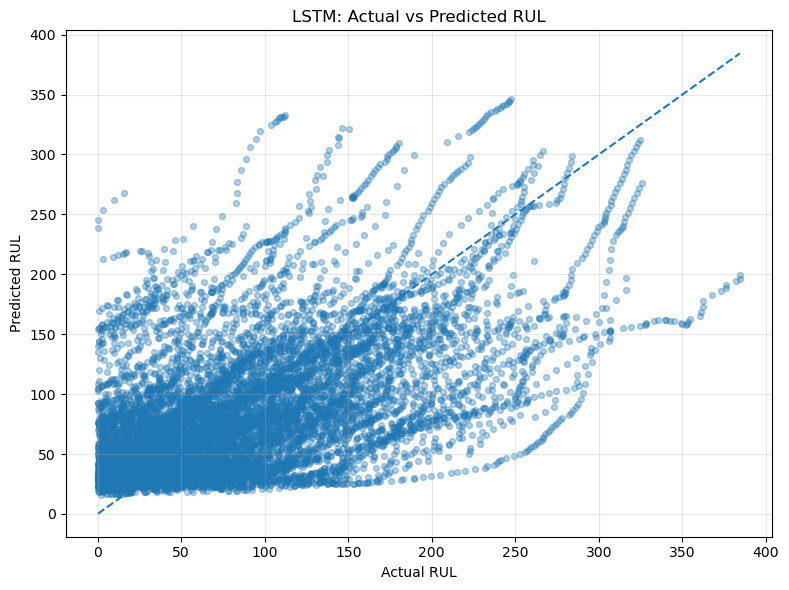

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual,
    y_test_pred,
    alpha=0.35,
    s=18
)

min_value = min(
    y_test_actual.min(),
    y_test_pred.min()
)

max_value = max(
    y_test_actual.max(),
    y_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM: Actual vs Predicted RUL")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "actual_vs_predicted_rul.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
residuals = y_test_pred - y_test_actual

print("===== RESIDUAL STATISTICS =====")

print(
    "Mean residual:",
    residuals.mean()
)

print(
    "Std residual :",
    residuals.std()
)

print(
    "Min residual :",
    residuals.min()
)

print(
    "Max residual :",
    residuals.max()
)

===== RESIDUAL STATISTICS =====
Mean residual: -2.969865
Std residual : 60.60155
Min residual : -204.29483
Max residual : 251.98813


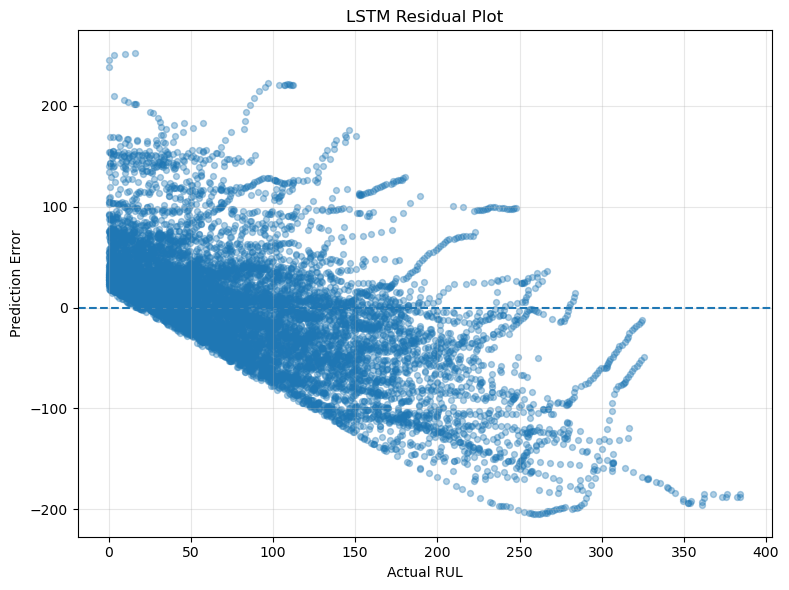

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_actual,
    residuals,
    alpha=0.35,
    s=18
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error")
plt.title("LSTM Residual Plot")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "lstm_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

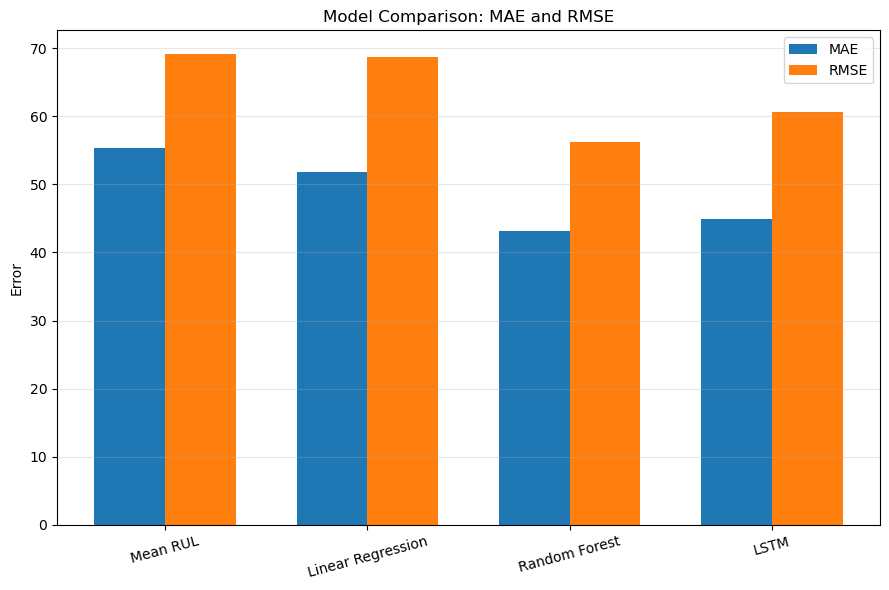

In [11]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    comparison["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    comparison["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    comparison["Model"],
    rotation=15
)

plt.ylabel("Error")
plt.title("Model Comparison: MAE and RMSE")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_mae_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

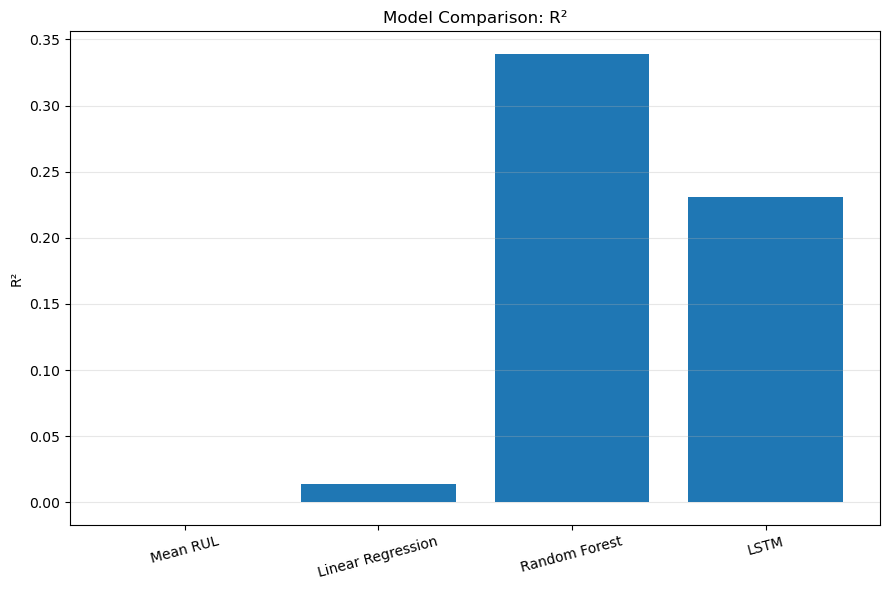

In [12]:
plt.figure(figsize=(9, 6))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.ylabel("R²")
plt.title("Model Comparison: R²")

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
prediction_results = pd.DataFrame({
    "Actual_RUL": y_test_actual,
    "Predicted_RUL": y_test_pred,
    "Residual": y_test_pred - y_test_actual,
    "Absolute_Error": np.abs(
        y_test_pred - y_test_actual
    )
})

prediction_results.to_csv(
    "lstm_test_predictions.csv",
    index=False
)

print(
    "Saved: lstm_test_predictions.csv"
)

Saved: lstm_test_predictions.csv


In [14]:
print("========== TASK 6 SUMMARY ==========")

print(
    f"Test samples        : {len(y_test_actual)}"
)

print(
    f"LSTM MAE            : {lstm_mae:.4f}"
)

print(
    f"LSTM RMSE           : {lstm_rmse:.4f}"
)

print(
    f"LSTM R²             : {lstm_r2:.4f}"
)

print(
    f"Prediction range    : "
    f"{y_test_pred.min():.2f} to {y_test_pred.max():.2f}"
)

print(
    f"Actual RUL range    : "
    f"{y_test_actual.min():.2f} to {y_test_actual.max():.2f}"
)

print("\nFiles generated:")
print("1. final_model_comparison_test.csv")
print("2. lstm_test_predictions.csv")
print("3. actual_vs_predicted_rul.png")
print("4. lstm_residual_plot.png")
print("5. model_comparison_mae_rmse.png")
print("6. model_comparison_r2.png")

========== TASK 6 SUMMARY ==========
Test samples        : 10075
LSTM MAE            : 44.9808
LSTM RMSE           : 60.6743
LSTM R²             : 0.2307
Prediction range    : 16.19 to 346.08
Actual RUL range    : 0.20 to 384.40

Files generated:
1. final_model_comparison_test.csv
2. lstm_test_predictions.csv
3. actual_vs_predicted_rul.png
4. lstm_residual_plot.png
5. model_comparison_mae_rmse.png
6. model_comparison_r2.png
